1.0 1.0624678136316401 0.9412049825602549
1.0 1.041043593428061 0.9605745679747105
1.0 1.0190466607443585 0.9813093340294684
1.0 0.9964198158003796 1.0035930479732025
1.0 0.9730939360506599 1.0276500170770146
1.0 0.9489848902476623 1.053757557445434
1.0 0.9239879513938503 1.0822651945747608
1.0 0.8979700749528704 1.1136228565884945
1.0 0.870756642320798 1.1484264964488058
1.0 0.8421100003825372 1.1874933198106419
1.0 0.8116905051773297 1.231996670678722
1.0 0.7789787505893444 1.283732064890653
1.0 0.7430989133022416 1.345715869178332
1.0 0.7023191287278573 1.423854141366398


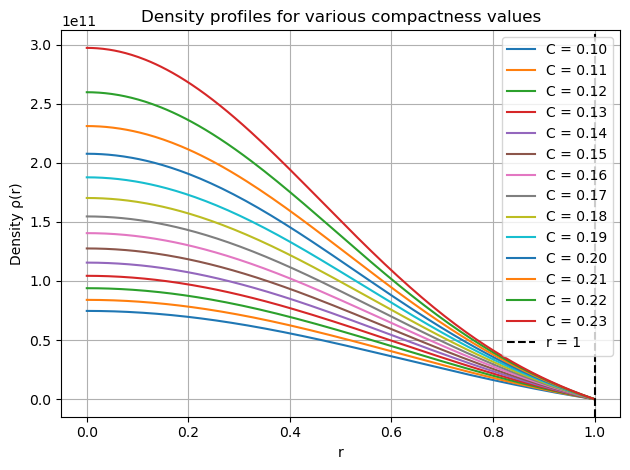

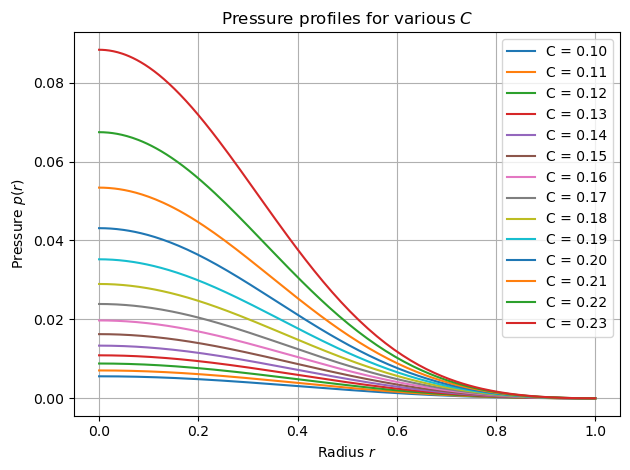

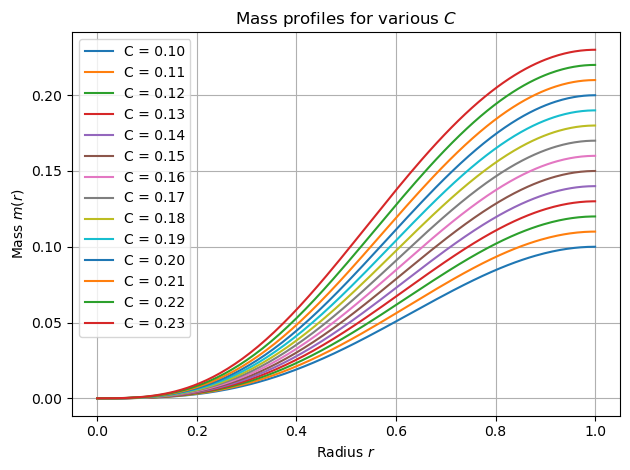

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import root_scalar
from scipy.interpolate import InterpolatedUnivariateSpline, CubicSpline, interp1d
import matplotlib.pyplot as plt
import cmath as cm

# Constants
K = 1.0             # Polytropic constant (dimensionless)
R_target = 1.0      # Target rescaled stellar radius
n = 1                # Polytropic index


"""def rho_from_p(p):
    p = np.maximum(p, 0.0)
    return pow((p / K),0.5) #np.sqrt(p / K)"""

def rho_from_p(p):
    return np.sqrt(np.maximum(p, 0.0) / K)

def energy_density_from_p(p):
    rho0 = rho_from_p(p)
    Gamma = 1 + 1/n
    return rho0 + (p/(Gamma-1))  # Total energy density for polytropic EOS


def tov_rhs(r, y):
    p, m, nu = y

    if p <= 0.0:
        return [0.0, 0.0, 0.0]

    rho0 = rho_from_p(p)
    eps  = energy_density_from_p(p) #rho0 + p  # total energy density

    dpdr = -(eps + p) * (m + 4*np.pi*r**3*p) / (r*(r - 2*m))
    dmdr = 4*np.pi * r**2 * eps
    dnudr = -2 * dpdr / (eps + p)

    return [dpdr, dmdr, dnudr]


# Solve TOV for a given p0
def solve_tov(p0):
    y0 = [p0, 0.0,0.0]
    sol = solve_ivp(
        tov_rhs,
        [1e-6, 10],  # integrate far enough to catch where p=0
        y0,
        method='RK45',
        rtol=1e-10,
        atol=1e-12,
        dense_output=True
    )
    r_vals = sol.t
    p_vals = sol.y[0]
    m_vals = sol.y[1]

    # Find where pressure becomes zero and interpolate to find R more accurately
    for i in range(1, len(p_vals)):
        if p_vals[i] <= 0:
            r1, r2 = r_vals[i-1], r_vals[i]
            p1, p2 = p_vals[i-1], p_vals[i]
            R_interp = r1 + (0 - p1) * (r2 - r1) / (p2 - p1)
            M_interp = m_vals[i-1] + (0 - p1) * (m_vals[i] - m_vals[i-1]) / (p2 - p1)
            return R_interp, M_interp, sol
    return r_vals[-1], m_vals[-1], sol  # fallback

# Shooting function to match compactness C = M/R
def shooting_target(p0, C_target):
    R, M, _ = solve_tov(p0)
    return M / R - C_target

# Define the values of compactness to solve for
C_vals = np.round(np.arange(0.10, 0.24, 0.01), 2)
profiles = {}

for C_target in C_vals:
    soln = root_scalar(
        shooting_target,
        args=(C_target,),
        bracket=[1e-6, 1.0],
        method='brentq',
        xtol=1e-12
    )

    if not soln.converged:
        raise RuntimeError(f"Root finding failed for C = {C_target}")

    p0 = soln.root
    R_raw, M_raw, sol = solve_tov(p0)
    scale_factor = R_target / R_raw
    print(R_target, R_raw, scale_factor)

    scale_factor = R_target / R_raw  # alpha

    r_vals = sol.t * scale_factor           # r -> alpha * r   (correct)
    p_vals = sol.y[0] * scale_factor**(-2)  # p -> alpha^{-2} * p    <-- FIXED
    m_vals = sol.y[1] * scale_factor        # m -> alpha * m         (correct)
    rho_vals = rho_from_p(p_vals)           # consistent with p
    nu_vals = sol.y[2]
    # Truncate where p goes to zero
    mask = p_vals > 0
    r_vals = r_vals[mask]
    p_vals = p_vals[mask]
    m_vals = m_vals[mask]
    rho_vals = rho_vals[mask]
    nu_vals = nu_vals[mask]

    R = R_raw * scale_factor
    M = M_raw * scale_factor

    if 2.0 * M / R >= 1.0:
        raise ValueError(f"Unphysical compactness encountered for C = {C_target}: 2M/R >= 1")

    nu_target_surface = np.log(1.0 - 2.0 * M / R)
    nu_raw_surface = nu_vals[-1]

    # Compute constant shift Δν
    delta_nu = nu_target_surface - nu_raw_surface

    # Apply the shift to entire profile
    nu_vals_normalized = nu_vals + delta_nu


    profiles[C_target] = {
        'r': r_vals,
        'r_raw': R_raw,
        'p': p_vals,
        'm': m_vals,
        'rho': rho_vals,
        'nu': nu_vals,
        'nu_vals_norm': nu_vals_normalized,
        'p0': p0,
        'R': R_raw * scale_factor,
        'M': M_raw * scale_factor,
        'M_raw': M_raw
    }


for C in C_vals:
    plt.plot(profiles[C]['r'], profiles[C]['rho']*1e12, label=f'C = {C:.2f}')
plt.axvline(1.0, color='black', linestyle='--', label='r = 1')
plt.xlabel('r')
plt.ylabel('Density ρ(r)')
plt.title('Density profiles for various compactness values')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Pressure
#plt.figure(figsize=(10, 6))
#plt.subplot(3,1,2)
for C in C_vals:
    plt.plot(profiles[C]['r'], profiles[C]['p'], label=f'C = {C:.2f}')
plt.xlabel('Radius $r$')
plt.ylabel('Pressure $p(r)$')
plt.title('Pressure profiles for various $C$')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Mass
#plt.figure(figsize=(10, 6))
#plt.subplot(3,1,3)
for C in C_vals:
    plt.plot(profiles[C]['r'], profiles[C]['m'], label=f'C = {C:.2f}')
plt.xlabel('Radius $r$')
plt.ylabel('Mass $m(r)$')
plt.title('Mass profiles for various $C$')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [3]:
def compactness_from_p0(p0):
    R, M, _ = solve_tov(p0)
    return M / R

p0_vals = np.logspace(-6, 2, 50)
C_vals_scan = [compactness_from_p0(p0) for p0 in p0_vals]

for p0, C in zip(p0_vals, C_vals_scan):
    print(f"p0 = {p0:.3e}, C = {C:.4f}")


p0 = 1.000e-06, C = 0.0020
p0 = 1.456e-06, C = 0.0024
p0 = 2.121e-06, C = 0.0029
p0 = 3.089e-06, C = 0.0035
p0 = 4.498e-06, C = 0.0042
p0 = 6.551e-06, C = 0.0050
p0 = 9.541e-06, C = 0.0061
p0 = 1.389e-05, C = 0.0073
p0 = 2.024e-05, C = 0.0088
p0 = 2.947e-05, C = 0.0105
p0 = 4.292e-05, C = 0.0126
p0 = 6.251e-05, C = 0.0151
p0 = 9.103e-05, C = 0.0181
p0 = 1.326e-04, C = 0.0216
p0 = 1.931e-04, C = 0.0258
p0 = 2.812e-04, C = 0.0306
p0 = 4.095e-04, C = 0.0363
p0 = 5.964e-04, C = 0.0429
p0 = 8.685e-04, C = 0.0505
p0 = 1.265e-03, C = 0.0591
p0 = 1.842e-03, C = 0.0689
p0 = 2.683e-03, C = 0.0799
p0 = 3.907e-03, C = 0.0919
p0 = 5.690e-03, C = 0.1051
p0 = 8.286e-03, C = 0.1191
p0 = 1.207e-02, C = 0.1338
p0 = 1.758e-02, C = 0.1489
p0 = 2.560e-02, C = 0.1641
p0 = 3.728e-02, C = 0.1790
p0 = 5.429e-02, C = 0.1933
p0 = 7.906e-02, C = 0.2065
p0 = 1.151e-01, C = 0.2183
p0 = 1.677e-01, C = 0.2284
p0 = 2.442e-01, C = 0.2366
p0 = 3.556e-01, C = 0.2428
p0 = 5.179e-01, C = 0.2467
p0 = 7.543e-01, C = 0.2484
p

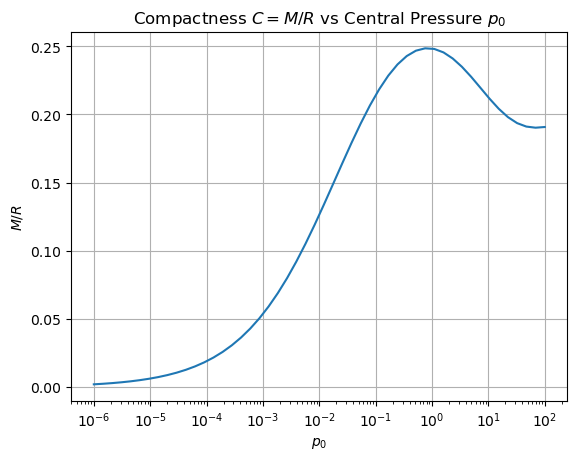

In [4]:
plt.plot(p0_vals, C_vals_scan)
plt.xscale('log')
plt.xlabel(r"$p_0$")
plt.ylabel(r"$M/R$")
plt.title("Compactness $C = M/R$ vs Central Pressure $p_0$")
plt.grid(True)

In [7]:
K_phys = 100.0        # km^2
alpha = np.sqrt(K_phys)  # 10 km

R_dimless, M_dimless, sol = solve_tov(p0)

r_dimless = sol.t
p_dimless = sol.y[0]
m_dimless = sol.y[1]
nu = sol.y[2]

mask = p_dimless > 0
r_dimless = r_dimless[mask]
p_dimless = p_dimless[mask]
m_dimless = m_dimless[mask]
nu = nu[mask]

# === Physical units ===
r_phys = alpha * r_dimless
m_phys = alpha * m_dimless
p_phys = p_dimless / alpha**2
rho0_phys = rho_from_p(p_dimless) / alpha**2
eps_phys = energy_density_from_p(p_dimless) / alpha**2

R_phys = alpha * R_dimless
M_phys = alpha * M_dimless

C = M_dimless / R_dimless

nu_surface_target = np.log(1 - 2*C)
delta_nu = nu_surface_target - nu[-1]
nu += delta_nu
print(f"Physical radius R = {R_phys:.2f} km, Mass M = {M_phys:.2f} km, Compactness C = {C:.4f}")

Physical radius R = 5.51 km, Mass M = 1.37 km, Compactness C = 0.2483


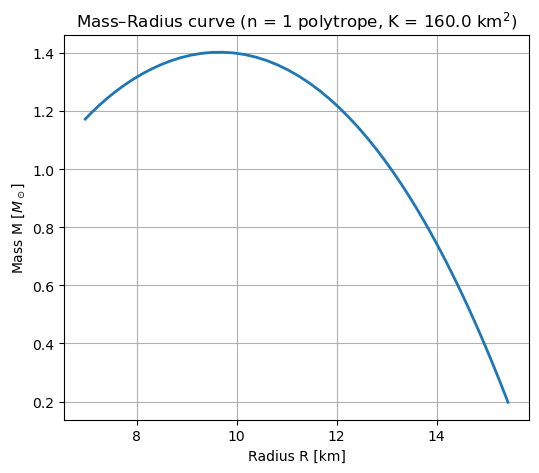

In [6]:
K_phys = 160.0    #160 needed to make M_max = 1.4 M_sun      # km^2  
alpha = np.sqrt(K_phys)  # 10 km

R_list = []
M_list = []
p0_vals = np.logspace(-4, 0, 60)  # covers low to near-max mass

for p0 in p0_vals:
    try:
        R_dim, M_dim, _ = solve_tov(p0)

        # Physical units
        R_phys = alpha * R_dim        # km
        M_phys = alpha * M_dim        # km

        R_list.append(R_phys)
        M_list.append(M_phys)

    except RuntimeError:
        continue
R_arr = np.array(R_list)
M_arr = np.array(M_list)
M_sun = M_arr / 1.4766

plt.figure(figsize=(6,5))
plt.plot(R_arr, M_sun, lw=2)

plt.xlabel("Radius R [km]")
plt.ylabel("Mass M [$M_\\odot$]")
plt.title("Mass–Radius curve (n = 1 polytrope, K = {} km$^2$)".format(K_phys))
plt.grid(True)

plt.show()


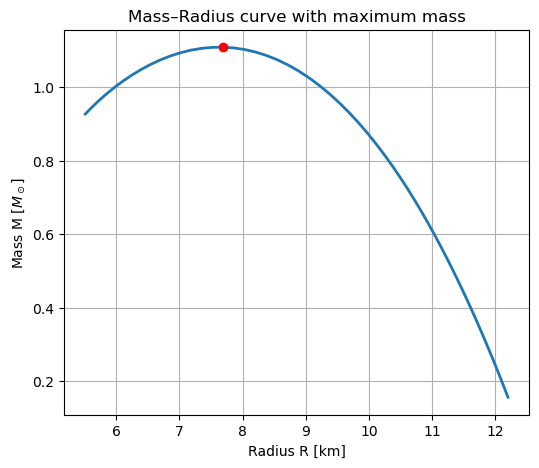

Maximum mass: 1.1086855738293062 M_sun
Radius at max mass: 7.691914667461933 km


In [8]:
imax = np.argmax(M_sun)

plt.figure(figsize=(6,5))
plt.plot(R_arr, M_sun, lw=2)
plt.scatter(R_arr[imax], M_sun[imax], color='red', zorder=5)

plt.xlabel("Radius R [km]")
plt.ylabel("Mass M [$M_\\odot$]")
plt.title("Mass–Radius curve with maximum mass")
plt.grid(True)

plt.show()

print("Maximum mass:", M_sun[imax], "M_sun")
print("Radius at max mass:", R_arr[imax], "km")


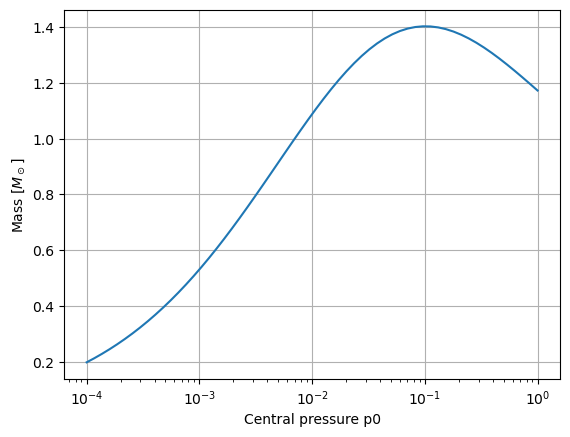

In [8]:
plt.plot(p0_vals[:len(M_sun)], M_sun)
plt.xscale("log")
plt.xlabel("Central pressure p0")
plt.ylabel("Mass [$M_\\odot$]")
plt.grid()


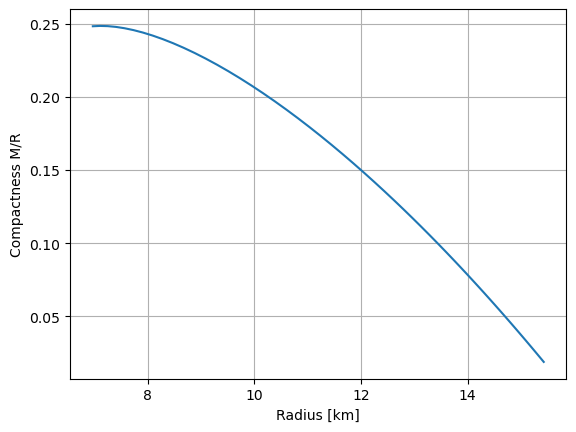

In [9]:
C_arr = M_arr / R_arr
plt.plot(R_arr, C_arr)
plt.xlabel("Radius [km]")
plt.ylabel("Compactness M/R")
plt.grid()


1.0 1.0624678136316401 0.9412049825602549
1.0 1.041043593428061 0.9605745679747105
1.0 1.0190466607443585 0.9813093340294684
1.0 0.9964198158003796 1.0035930479732025
1.0 0.9730939360506599 1.0276500170770146
1.0 0.9489848902476623 1.053757557445434
1.0 0.9239879513938503 1.0822651945747608
1.0 0.8979700749528704 1.1136228565884945
1.0 0.870756642320798 1.1484264964488058
1.0 0.8421100003825372 1.1874933198106419
1.0 0.8116905051773297 1.231996670678722
1.0 0.7789787505893444 1.283732064890653
1.0 0.7430989133022416 1.345715869178332
1.0 0.7023191287278573 1.423854141366398


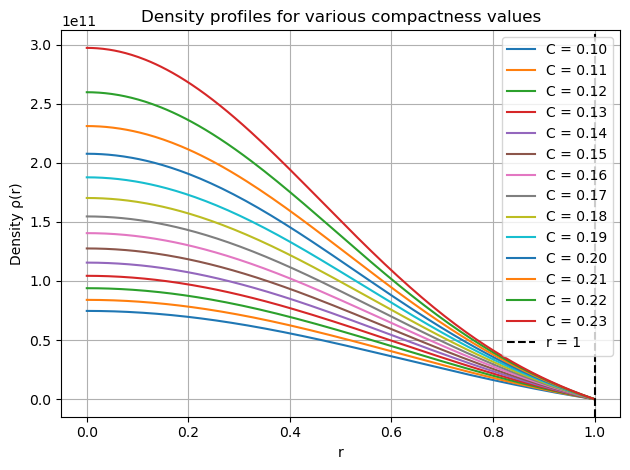

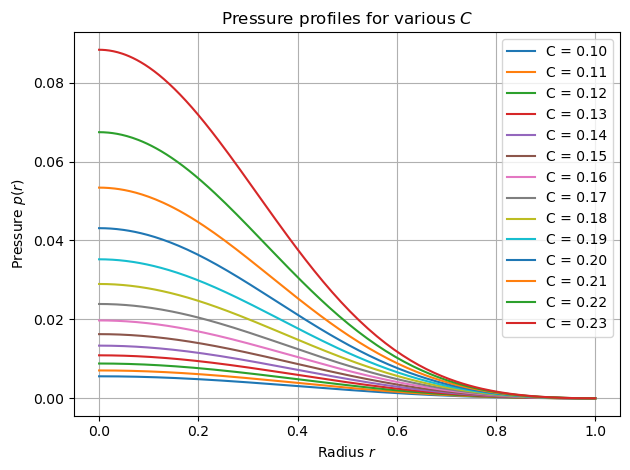

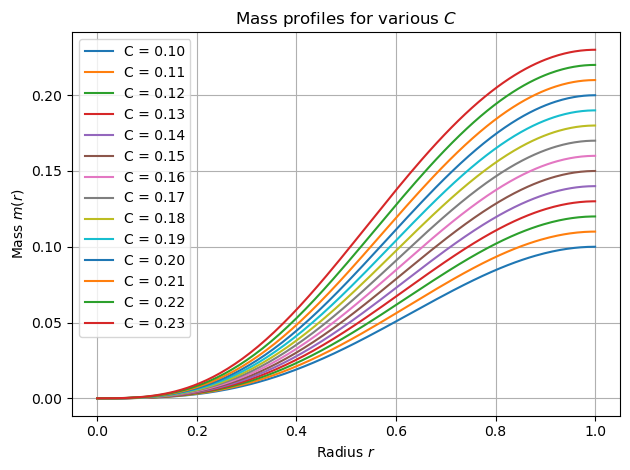

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import root_scalar
from scipy.interpolate import InterpolatedUnivariateSpline, CubicSpline, interp1d
import matplotlib.pyplot as plt
import cmath as cm

# Constants
K = 1.0             # Polytropic constant (dimensionless)
R_target = 1.0      # Target rescaled stellar radius
n = 1                # Polytropic index


"""def rho_from_p(p):
    p = np.maximum(p, 0.0)
    return pow((p / K),0.5) #np.sqrt(p / K)"""

def rho_from_p(p):
    return np.sqrt(np.maximum(p, 0.0) / K)

def energy_density_from_p(p):
    rho0 = rho_from_p(p)
    Gamma = 1 + 1/n
    return rho0 + (p/(Gamma-1))  # Total energy density for polytropic EOS


def tov_rhs(r, y):
    p, m, nu = y

    if p <= 0.0:
        return [0.0, 0.0, 0.0]

    rho0 = rho_from_p(p)
    eps  = energy_density_from_p(p) #rho0 + p  # total energy density

    dpdr = -(eps + p) * (m + 4*np.pi*r**3*p) / (r*(r - 2*m))
    dmdr = 4*np.pi * r**2 * eps
    dnudr = -2 * dpdr / (eps + p)

    return [dpdr, dmdr, dnudr]


# Solve TOV for a given p0
def solve_tov(p0):
    y0 = [p0, 0.0,0.0]
    sol = solve_ivp(
        tov_rhs,
        [1e-6, 10],  # integrate far enough to catch where p=0
        y0,
        method='RK45',
        rtol=1e-10,
        atol=1e-12,
        dense_output=True
    )
    r_vals = sol.t
    p_vals = sol.y[0]
    m_vals = sol.y[1]

    # Find where pressure becomes zero and interpolate to find R more accurately
    for i in range(1, len(p_vals)):
        if p_vals[i] <= 0:
            r1, r2 = r_vals[i-1], r_vals[i]
            p1, p2 = p_vals[i-1], p_vals[i]
            R_interp = r1 + (0 - p1) * (r2 - r1) / (p2 - p1)
            M_interp = m_vals[i-1] + (0 - p1) * (m_vals[i] - m_vals[i-1]) / (p2 - p1)
            return R_interp, M_interp, sol
    return r_vals[-1], m_vals[-1], sol  # fallback

# Shooting function to match compactness C = M/R
def shooting_target(p0, C_target):
    R, M, _ = solve_tov(p0)
    return M / R - C_target

# Define the values of compactness to solve for
C_vals = np.round(np.arange(0.10, 0.24, 0.01), 2)
profiles = {}

for C_target in C_vals:
    soln = root_scalar(
        shooting_target,
        args=(C_target,),
        bracket=[1e-6, 1.0],
        method='brentq',
        xtol=1e-12
    )

    if not soln.converged:
        raise RuntimeError(f"Root finding failed for C = {C_target}")

    p0 = soln.root
    R_raw, M_raw, sol = solve_tov(p0)
    scale_factor = R_target / R_raw
    print(R_target, R_raw, scale_factor)

    scale_factor = R_target / R_raw  # alpha

    r_vals = sol.t * scale_factor           # r -> alpha * r   (correct)
    p_vals = sol.y[0] * scale_factor**(-2)  # p -> alpha^{-2} * p    <-- FIXED
    m_vals = sol.y[1] * scale_factor        # m -> alpha * m         (correct)
    rho_vals = rho_from_p(p_vals)           # consistent with p
    nu_vals = sol.y[2]
    # Truncate where p goes to zero
    mask = p_vals > 0
    r_vals = r_vals[mask]
    p_vals = p_vals[mask]
    m_vals = m_vals[mask]
    rho_vals = rho_vals[mask]
    nu_vals = nu_vals[mask]

    R = R_raw * scale_factor
    M = M_raw * scale_factor

    if 2.0 * M / R >= 1.0:
        raise ValueError(f"Unphysical compactness encountered for C = {C_target}: 2M/R >= 1")

    nu_target_surface = np.log(1.0 - 2.0 * M / R)
    nu_raw_surface = nu_vals[-1]

    # Compute constant shift Δν
    delta_nu = nu_target_surface - nu_raw_surface

    # Apply the shift to entire profile
    nu_vals_normalized = nu_vals + delta_nu


    profiles[C_target] = {
        'r': r_vals,
        'r_raw': R_raw,
        'p': p_vals,
        'm': m_vals,
        'rho': rho_vals,
        'nu': nu_vals,
        'nu_vals_norm': nu_vals_normalized,
        'p0': p0,
        'R': R_raw * scale_factor,
        'M': M_raw * scale_factor,
        'M_raw': M_raw
    }


for C in C_vals:
    plt.plot(profiles[C]['r'], profiles[C]['rho']*1e12, label=f'C = {C:.2f}')
plt.axvline(1.0, color='black', linestyle='--', label='r = 1')
plt.xlabel('r')
plt.ylabel('Density ρ(r)')
plt.title('Density profiles for various compactness values')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Pressure
#plt.figure(figsize=(10, 6))
#plt.subplot(3,1,2)
for C in C_vals:
    plt.plot(profiles[C]['r'], profiles[C]['p'], label=f'C = {C:.2f}')
plt.xlabel('Radius $r$')
plt.ylabel('Pressure $p(r)$')
plt.title('Pressure profiles for various $C$')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Mass
#plt.figure(figsize=(10, 6))
#plt.subplot(3,1,3)
for C in C_vals:
    plt.plot(profiles[C]['r'], profiles[C]['m'], label=f'C = {C:.2f}')
plt.xlabel('Radius $r$')
plt.ylabel('Mass $m(r)$')
plt.title('Mass profiles for various $C$')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

p0 = 1.000e-06, C = 0.0020
p0 = 1.456e-06, C = 0.0024
p0 = 2.121e-06, C = 0.0029
p0 = 3.089e-06, C = 0.0035
p0 = 4.498e-06, C = 0.0042
p0 = 6.551e-06, C = 0.0050
p0 = 9.541e-06, C = 0.0061
p0 = 1.389e-05, C = 0.0073
p0 = 2.024e-05, C = 0.0088
p0 = 2.947e-05, C = 0.0105
p0 = 4.292e-05, C = 0.0126
p0 = 6.251e-05, C = 0.0151
p0 = 9.103e-05, C = 0.0181
p0 = 1.326e-04, C = 0.0216
p0 = 1.931e-04, C = 0.0258
p0 = 2.812e-04, C = 0.0306
p0 = 4.095e-04, C = 0.0363
p0 = 5.964e-04, C = 0.0429
p0 = 8.685e-04, C = 0.0505
p0 = 1.265e-03, C = 0.0591
p0 = 1.842e-03, C = 0.0689
p0 = 2.683e-03, C = 0.0799
p0 = 3.907e-03, C = 0.0919
p0 = 5.690e-03, C = 0.1051
p0 = 8.286e-03, C = 0.1191
p0 = 1.207e-02, C = 0.1338
p0 = 1.758e-02, C = 0.1489
p0 = 2.560e-02, C = 0.1641
p0 = 3.728e-02, C = 0.1790
p0 = 5.429e-02, C = 0.1933
p0 = 7.906e-02, C = 0.2065
p0 = 1.151e-01, C = 0.2183
p0 = 1.677e-01, C = 0.2284
p0 = 2.442e-01, C = 0.2366
p0 = 3.556e-01, C = 0.2428
p0 = 5.179e-01, C = 0.2467
p0 = 7.543e-01, C = 0.2484
p

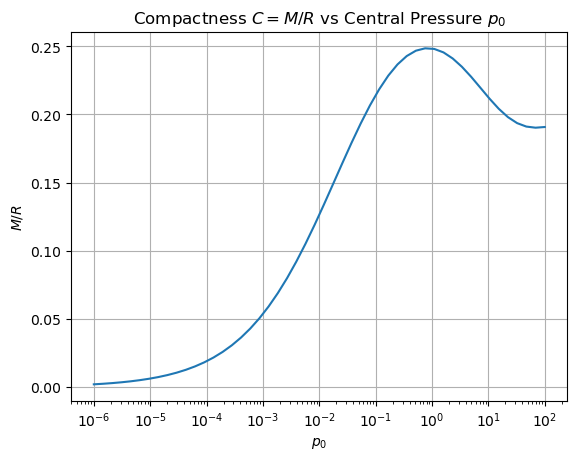

In [2]:
def compactness_from_p0(p0):
    R, M, _ = solve_tov(p0)
    return M / R

p0_vals = np.logspace(-6, 2, 50)
C_vals_scan = [compactness_from_p0(p0) for p0 in p0_vals]

for p0, C in zip(p0_vals, C_vals_scan):
    print(f"p0 = {p0:.3e}, C = {C:.4f}")

plt.plot(p0_vals, C_vals_scan)
plt.xscale('log')
plt.xlabel(r"$p_0$")
plt.ylabel(r"$M/R$")
plt.title("Compactness $C = M/R$ vs Central Pressure $p_0$")
plt.grid(True)